In [66]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import random 

In [67]:
def mse(a,b):
    error = np.mean((a - b)**2)
    return error
def r_sq(a, b):
    ss_total = np.sum((a - np.mean(a))**2)
    ss_residuals = np.sum((a - b)**2)
    return 1 - (ss_residuals / ss_total)

In [68]:
X_1_ls = np.random.uniform(0,5,10)
X_1_ls.sort()
Y_1_ls = np.random.uniform(0,25,10)

A_1_ls = np.vstack([X_1_ls, np.ones(len(X_1_ls))]).T

In [69]:
m_1_ls, c_1_ls = np.linalg.lstsq(A_1_ls, Y_1_ls, rcond=None)[0]

print(f" the least squares solution is m = {m_1_ls} and c = {c_1_ls}")

X_line_1 = X_1_ls
Y_line_1 = m_1_ls * X_line_1 + c_1_ls

cf = np.polyfit(X_1_ls,Y_1_ls,3)
poly = np.poly1d(cf)
Y_poly = poly(X_1_ls)

 the least squares solution is m = 1.9824754517236647 and c = 11.471931940518715


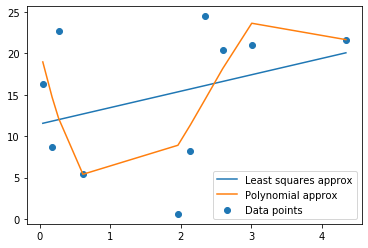

In [70]:
plt.scatter(X_1_ls,Y_1_ls, label = "Data points")
plt.plot(X_line_1,Y_line_1, label = "Least squares approx")
plt.plot(X_1_ls,Y_poly, label = "Polynomial approx")
plt.legend()

In [84]:
#i know my variable naming is very bad, I apologize I am doing this very late and I realized this.

print(f" mean squared for linear approx {mse(Y_1_ls,Y_line_1)}")
print(f"\n r squared for linear approx {r_sq(Y_1_ls,Y_line_1)}")
print(f"\n mean squared for poly approx {mse(Y_1_ls,Y_poly)}")
print(f"\n r squared for poly approx {r_sq(Y_1_ls,Y_poly)}")

mse_linear = mse(Y_1_ls,Y_line_1)
mse_poly = mse(Y_1_ls,Y_poly)
rsq_linear = r_sq(Y_1_ls,Y_line_1)
rsq_poly = r_sq(Y_1_ls,Y_poly)

if mse_poly < mse_linear and rsq_poly > rsq_linear:
    print("\nPolynomial is the better fit")
else:
    print("\nLinear least squares is the better fit")

#mean squared values are really high and r squared values are really low due to the random nature and inherent lack of relationship between the x and y values.

 mean squared for linear approx 57.16184331222162

 r squared for linear approx 0.1125598253709964

 mean squared for poly approx 34.76354484136542

 r squared for poly approx 0.46029441114701675

Polynomial is the better fit


The polynomial approximation was a better fit due to a slightly lower mean squared error value and higher value for R squared. 

polynomial degree: 3

 mean squared: 34.76354484136542

 r squared: 0.46029441114701675


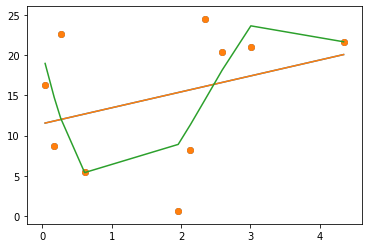

polynomial degree: 4

 mean squared: 33.66798445052041

 r squared: 0.4773030352261539


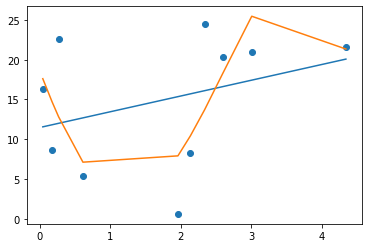

polynomial degree: 5

 mean squared: 17.854747350788227

 r squared: 0.7228042486244934


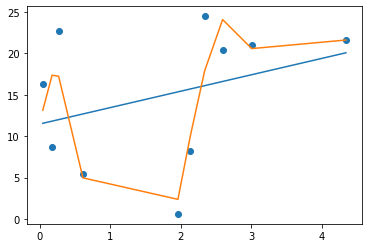

polynomial degree: 6

 mean squared: 17.49045334786198

 r squared: 0.7284599293170726


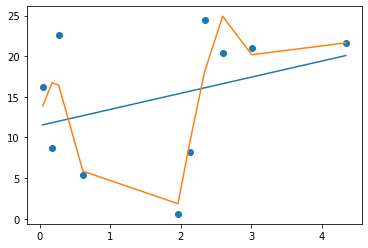

polynomial degree: 7

 mean squared: 11.101375319983987

 r squared: 0.8276506515232984


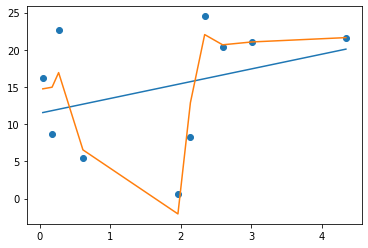

polynomial degree: 8

 mean squared: 6.6466224733309955

 r squared: 0.8968108887565426


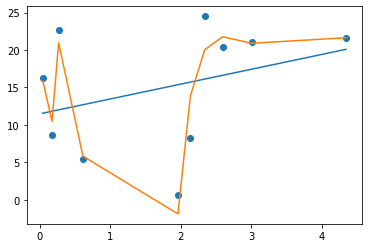

polynomial degree: 9

 mean squared: 3.191959050348315e-17

 r squared: 1.0


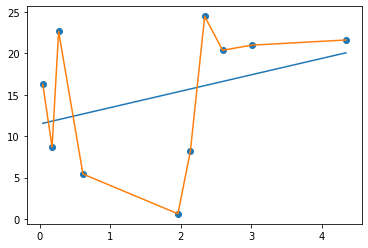

In [89]:
plt.figure()
plt.scatter(X_1_ls,Y_1_ls)
plt.plot(X_line_1,Y_line_1)

for i in range(3,10):
    cf_n = np.polyfit(X_1_ls,Y_1_ls,i)
    poly_n = np.poly1d(cf_n)
    
    y_poly_n = poly_n(X_1_ls)
    
    print(f"polynomial degree: {i}")
    print(f"\n mean squared: {mse(Y_1_ls, y_poly_n)}")
    print(f"\n r squared: {r_sq(Y_1_ls, y_poly_n)}")
    
    plt.scatter(X_1_ls,Y_1_ls)
    plt.plot(X_line_1,Y_line_1)
    plt.plot(X_1_ls,y_poly_n)
    plt.show()
    


i stopped at degree 8 because at 9, the polynomial would be able to individually fit every point and it wouldn't really give a best fit polynomial. The overfitting started at around degree 7/8 as the model reaches a higher degree and starts to bend and to fit the points better. The r squared value here also breaks 0.8 The blatant overfit is shown at degree 9 with the r squared value being a perfect 1.

polynomial degree: 8

 mean squared: 6.6466224733309955

 r squared: 0.8968108887565426


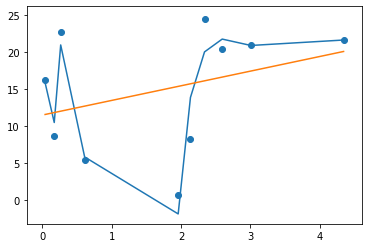

polynomial degree: 7

 mean squared: 11.101375319983987

 r squared: 0.8276506515232984


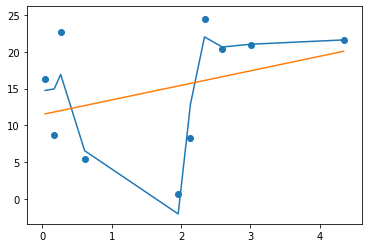

polynomial degree: 6

 mean squared: 17.49045334786198

 r squared: 0.7284599293170726


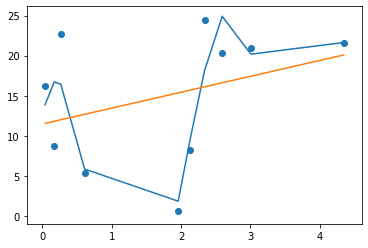

polynomial degree: 5

 mean squared: 17.854747350788227

 r squared: 0.7228042486244934


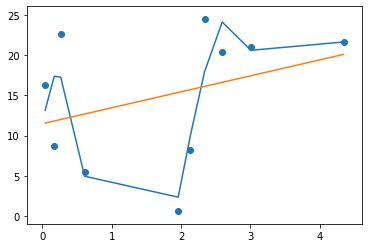

polynomial degree: 4

 mean squared: 33.66798445052041

 r squared: 0.4773030352261539


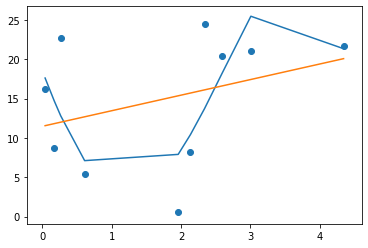

polynomial degree: 3

 mean squared: 34.76354484136542

 r squared: 0.46029441114701675


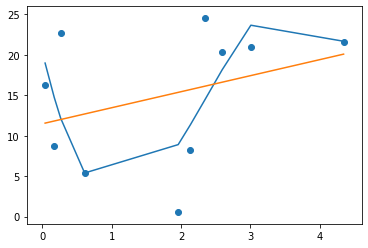

polynomial degree: 2

 mean squared: 52.35633876041161

 r squared: 0.1871654985181208


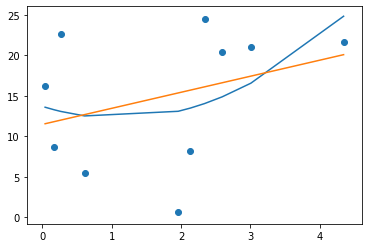

polynomial degree: 1

 mean squared: 57.16184331222162

 r squared: 0.1125598253709964


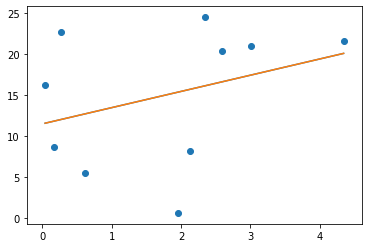

In [77]:
plt.figure()


for i in range(9,0,-1):
    cf_n2 = np.polyfit(X_1_ls,Y_1_ls,i)
    poly_n2 = np.poly1d(cf_n2)
    
    y_poly_n2 = poly_n2(X_1_ls)
    
    print(f"polynomial degree: {i}")
    print(f"\n mean squared: {mse(Y_1_ls, y_poly_n2)}")
    print(f"\n r squared: {r_sq(Y_1_ls, y_poly_n2)}")
    
    plt.plot(X_1_ls,y_poly_n2)
    plt.scatter(X_1_ls,Y_1_ls)
    plt.plot(X_line_1,Y_line_1)
    plt.show()
    

at about degree 3 or 2, the polynomial approximation began severly underfitting it and this is reflected in the r squared values dropping sharply from 3 to 2.

mean squared for polynomial is 34.76354484136543

r squared for polynomial is 0.46029441114701675


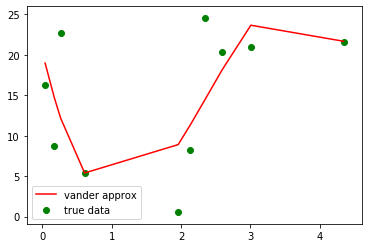

In [88]:
degree = 3
V = np.vander(X_1_ls, N=degree+1, increasing=True)
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, Y_1_ls)
cf_v = np.linalg.solve(VT_V, VT_y)

#flips coefficient order to read properly
poly_V = np.poly1d(cf_v[::-1])

Y_vander = poly_V(X_1_ls)


print(f"mean squared for polynomial is {mse(Y_1_ls,Y_vander)}")
print(f"\nr squared for polynomial is {r_sq(Y_1_ls,Y_vander)}")


plt.plot(X_1_ls,Y_vander,color = 'red',label ='vander approx')
plt.scatter(X_1_ls,Y_1_ls, color = 'green', label = 'true data')
plt.legend()
plt.show()
